# Week 7 Assignment: ARIA v4.0 (The Accessible Auditor)

**Student Worksheet** — Fill in the code cells using AI assistance or your own code.

**Submission Deadline**: Before next class

**Learning Objectives**:
- Master OSMnx road network extraction and projection
- Implement betweenness centrality analysis
- Construct rainfall → congestion dynamic weighting system
- Calculate pre/post-disaster isochrones and accessibility changes
- (Advanced) Use AI to generate disaster response recommendations

---


## Part 0: Environment Setup

Confirm the following packages are installed:`osmnx`, `networkx`, `geopandas`, `pandas`, `numpy`, `matplotlib`, `shapely`


In [1]:
# [S1] Environment Setup
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import warnings
warnings.filterwarnings('ignore')

# Check version
print(f"OSMnx: {ox.__version__}")
print(f"NetworkX: {nx.__version__}")
print(f"GeoPandas: {gpd.__version__}")

# Font configuration (If Chinese language support is needed)
rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'DejaVu Sans']  # fallback
rcParams['axes.unicode_minus'] = False


OSMnx: 2.0.6
NetworkX: 3.4.2
GeoPandas: 1.1.1


## Part A: Road Network Extraction & Travel Time Calculation

### Task A.1: Road Network Extraction

Use OSMnx to extract from OpenStreetMap**花蓮** (or choose your own township) road network.

**Tips**:
- Use `ox.graph_from_place()` or `ox.graph_from_address()`
- Set `network_type='drive'` Extract only car roads
- OSMnx ≥2.0 Road network already auto-simplified,no additional calls needed `simplify_graph()`
- use `ox.project_graph(G, to_crs='EPSG:3826')` Project to meter coordinates

In [2]:
# [S2] Attempt Road Network Extraction
# If using place name, confirm the location exists (e.g., "Hualien City, Taiwan")

place_name = "Hualien City, Taiwan"  # TODO: Change to your chosen location
network_type = 'drive'
dist_meters = 5000  # Search radius (meters)

print(f"📍 Extracting {place_name} road network...")

try:
    # TODO: Use ox.graph_from_address() to extract road network
    G = ox.graph_from_address(place_name, dist=dist_meters, network_type=network_type)
    print(f"✅ Extraction successful: {G.number_of_nodes()} Node(s), {G.number_of_edges()} edge(s)")
except Exception as e:
    print(f"❌ Extraction failed: {e}")
    print("Possible causes:")
    print("  - Location name does not existor format error")
    print("  - Network connection issue (Overpass API Timeout)")
    print("  - Recommend waiting a few minutes and retry,oruse ox.settings.timeout = 300")


📍 Extracting Hualien City, Taiwan road network...
✅ Extraction successful: 3421 Node(s), 9815 edge(s)


In [3]:
# [S3] Project to Meter Coordinates
# Note: OSMnx >=2.0 automatically simplifies, no manual call needed simplify_graph()

# TODO: Project to EPSG:3826 (TWD97/TM2)
G_proj = ox.project_graph(G, to_crs='EPSG:3826')

print(f"Node count: {G_proj.number_of_nodes()}")
print(f"Number of edges: {G_proj.number_of_edges()}")
print(f"CRS: {G_proj.graph['crs']}")
print("✅ Projection complete")


Node count: 3421
Number of edges: 9815
CRS: EPSG:3826
✅ Projection complete


In [4]:
# [S4] Calculate Travel Time
# Calculate base travel time for each edge (unit: seconds)

# Highway type speed reference table (consistent with Demo Cell [3])
speed_defaults = {
    'motorway': 110, 'motorway_link': 80,
    'trunk': 100, 'trunk_link': 60,
    'primary': 80, 'primary_link': 50,
    'secondary': 60, 'secondary_link': 40,
    'tertiary': 50, 'tertiary_link': 30,
    'residential': 40, 'living_street': 10,
    'unclassified': 30,
}

def get_speed_kph(data):
    """From OSM edge data Get speed (km/h),and Demo Cell [3] Consistent."""
    maxspeed = data.get('maxspeed', None)
    if maxspeed:
        try:
            return float(maxspeed)
        except (ValueError, TypeError):
            if isinstance(maxspeed, list):
                try:
                    return float(maxspeed[0])
                except:
                    pass
    highway = data.get('highway', 'residential')
    if isinstance(highway, list):
        highway = highway[0]
    return speed_defaults.get(highway, 40)

# TODO: Traverse all edges,Calculate travel_time_normal
for u, v, k, data in G_proj.edges(data=True, keys=True):
    length = data['length']  # meters
    speed_kph = get_speed_kph(data)
    speed_ms = speed_kph / 3.6  # Convert to m/s
    data['travel_time_normal'] = length / speed_ms  # seconds
    data['speed_kph'] = speed_kph

# Check
sample_edge = list(G_proj.edges(data=True, keys=True))[0]
print(f"Sample edges: length={sample_edge[3]['length']:.1f}m, "
      f"speed={sample_edge[3]['speed_kph']:.0f}km/h, "
      f"travel_time={sample_edge[3]['travel_time_normal']:.1f}s")
print("✅ Travel time calculation complete")


Sample edges: length=17.7m, speed=30km/h, travel_time=2.1s
✅ Travel time calculation complete


## Part B: Bottleneck & Risk Assessment

### Task B.1: Calculate Betweenness Centrality & Identify Top 5


In [5]:
# [S5] Calculate Centrality
# Use NetworkX betweenness_centrality
# Use 'length' (road segment length) as weight

print("⏳ Calculating Betweenness Centrality...")

# TODO: Use nx.betweenness_centrality() Calculate
centrality = nx.betweenness_centrality(G_proj, weight='length')

print("✅ Calculation complete")

# TODO: Find Top 5 Node(s)
top_5_nodes = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:5]

print("\nTop 5 Bottleneck Node(s):")
for rank, (node_id, cent_val) in enumerate(top_5_nodes, 1):
    print(f"{rank}. Node(s) {node_id}: Centrality = {cent_val:.6f}")


⏳ Calculating Betweenness Centrality...
✅ Calculation complete

Top 5 Bottleneck Node(s):
1. Node(s) 649286213: Centrality = 0.140247
2. Node(s) 649286214: Centrality = 0.139444
3. Node(s) 1061487893: Centrality = 0.125307
4. Node(s) 929963021: Centrality = 0.123480
5. Node(s) 1074772659: Centrality = 0.115733


### Task B.2: Overlay Top 5 with Terrain Risk (Using Week 4 Data)


In [7]:
# [S6] Terrain Risk Overlay (Advanced Option)
# If you have Week 4 terrain risk data, overlay it with bottleneck nodes
# If W4 data is not available, you can skip this step without affecting subsequent analysis
from shapely.geometry import Point
# Step 1: Convert Top 5 Nodes to GeoDataFrame
top_5_gdf = gpd.GeoDataFrame(
    [{'node_id': nid, 'centrality': cv,
      'geometry': Point(G_proj.nodes[nid]['x'], G_proj.nodes[nid]['y'])}
     for nid, cv in top_5_nodes],
    crs=G_proj.graph['crs']
)
print(f"✅ Top 5 Node(s) GeoDataFrame Establishment complete")
print(top_5_gdf[['node_id', 'centrality']])

# Step 2 (Optional): Overlay W4 Terrain risk
# If you have terrain_gdf,Uncomment the following:
# terrain_gdf = gpd.read_file('path/to/terrain_risk.geojson')
# top_5_with_risk = gpd.sjoin(top_5_gdf, terrain_gdf, how='left', predicate='within')
# print(top_5_with_risk[['node_id', 'centrality', 'terrain_risk']])


✅ Top 5 Node(s) GeoDataFrame Establishment complete
      node_id  centrality
0   649286213    0.140247
1   649286214    0.139444
2  1061487893    0.125307
3   929963021    0.123480
4  1074772659    0.115733


### Task B.3: Visualization


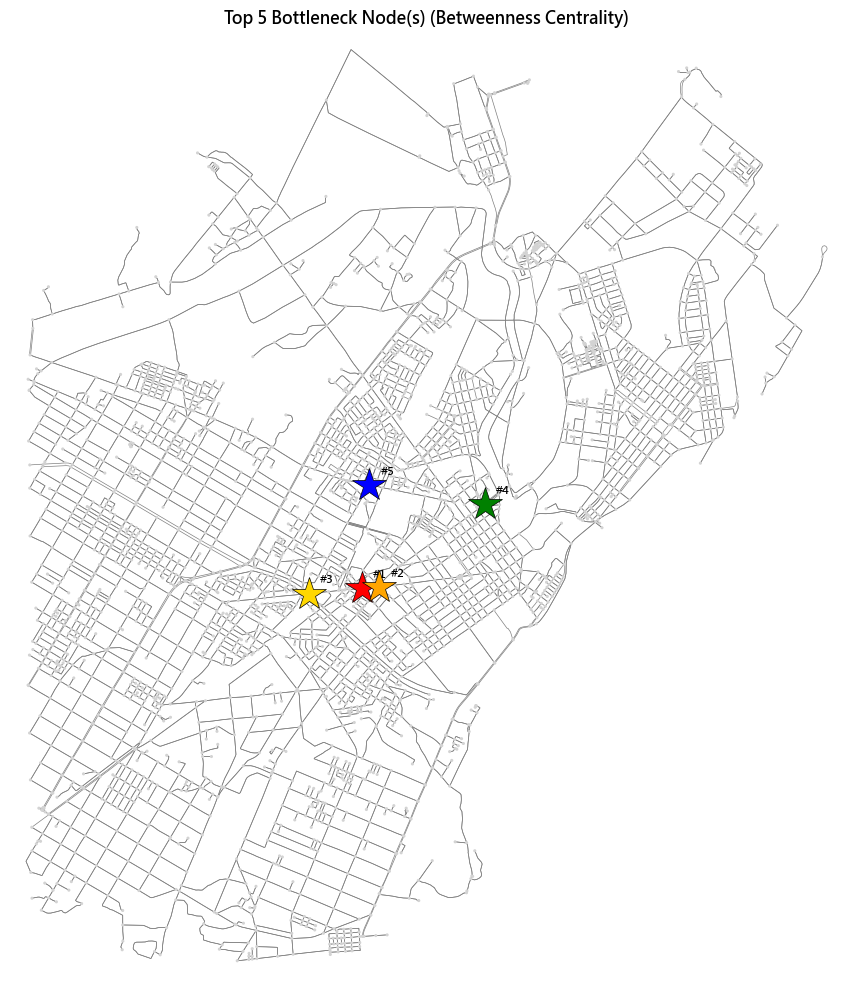

✅ Visualization complete


In [8]:
# [S7] Visualize Bottlenecks

fig, ax = plt.subplots(figsize=(12, 10))

# Draw the entire road network
ox.plot_graph(G_proj, ax=ax, node_size=5, node_color='lightgray',
             edge_color='gray', edge_linewidth=0.5, show=False)

# Mark Top 5 Node(s) (Star marker)
colors = ['red', 'orange', 'gold', 'green', 'blue']
for rank, (node_id, cent_val) in enumerate(top_5_nodes):
    x = G_proj.nodes[node_id]['x']
    y = G_proj.nodes[node_id]['y']
    ax.plot(x, y, marker='*', markersize=25, color=colors[rank],
           markeredgecolor='black', markeredgewidth=0.5, zorder=10)
    ax.annotate(f'#{rank+1}', (x, y), fontsize=8, fontweight='bold',
               textcoords='offset points', xytext=(8, 8))

ax.set_title('Top 5 Bottleneck Node(s) (Betweenness Centrality)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Visualization complete")


## Part C: Dynamic Accessibility Analysis

> **⏱️ Lab 2 Scope (30 min in class)**:Complete the **core calculations** of C.1 ~ C.3 (print contraction ratiovalues).
> Part D visualization can be completed during assignment time, not required in class.

### Task C.1: Define Rainfall → Traffic Congestion Mapping


In [9]:
# [S8] Define rain_to_congestion Function
import math

def rain_to_congestion(rainfall_mm, method='threshold'):
    """
    Rainfall → Congestion Factor mapping
    
    Parameters
    ----------
    rainfall_mm : float
        Rainfall intensity (mm/hr)
    method : str
        Mapping method ('linear', 'exponential', 'threshold')
    
    Returns
    -------
    cf : float
        Congestion Factor (0 ≤ cf ≤ 0.9)
    """
    
    # 防呆：處理 None、字串、負值等情況
    try:
        rain = float(rainfall_mm)
    except (TypeError, ValueError):
        return 0.0
    
    if rain < 0:
        rain = 0.0

    # 1) Threshold method：與課堂 Slide 12 一致
    if method == 'threshold':
        if rain < 10:
            cf = 0.0
        elif rain < 40:
            cf = 0.3
        elif rain < 80:
            cf = 0.6
        else:
            cf = 0.9

    # 2) Linear method
    elif method == 'linear':
        cf = min((rain / 100.0) * 0.9, 0.9)

    # 3) Exponential method
    elif method == 'exponential':
        cf = 0.95 * (1 - math.exp(-rain / 50.0))
        cf = min(cf, 0.9)

    else:
        raise ValueError("method must be 'threshold', 'linear', or 'exponential'")
    
    return round(cf, 3)


# Testing
rain_test = [0, 10, 40, 80, 100, 130.5]
for rain in rain_test:
    cf = rain_to_congestion(rain, method='threshold')
    print(f"Rainfall {rain:.1f} mm/hr → Congestion Factor {cf}")

Rainfall 0.0 mm/hr → Congestion Factor 0.0
Rainfall 10.0 mm/hr → Congestion Factor 0.3
Rainfall 40.0 mm/hr → Congestion Factor 0.6
Rainfall 80.0 mm/hr → Congestion Factor 0.9
Rainfall 100.0 mm/hr → Congestion Factor 0.9
Rainfall 130.5 mm/hr → Congestion Factor 0.9


### Task C.2: Load Rainfall Data (W5/W6) and Apply Dynamic Weights


In [11]:
# [S9] Load Rainfall Data

# Option A: Use W6 Kriging GeoTIFF
# kriging_path = "path/to/kriging_rainfall.tif"
# rainfall_raster = rasterio.open(kriging_path)

# Option B: Use W5 rainfall station(s) JSON
# rainfall_json_path = "path/to/fungwong_202511.json"
# with open(rainfall_json_path) as f:
#     rainfall_data = json.load(f)

# TODO: Choose any of the above methods to read rainfall data
# [S9] Load Rainfall Data

import os
import json
import rasterio

# ==============================
# Choose rainfall data source
# ==============================
# 可選：
# - "raster" : 使用 W6 Kriging GeoTIFF
# - "json"   : 使用 W5 rainfall station(s) JSON
use_mode = "json"   # <-- 請改成 "raster" 或 "json"


# ==============================
# Option A: W6 Kriging GeoTIFF
# ==============================
kriging_path = "../data/kriging_rainfall.tif"

# ==============================
# Option B: W5 rainfall station(s) JSON
# ==============================
rainfall_json_path = "../data/scenarios/fungwong_202511.json"


# ==============================
# Read rainfall data
# ==============================
rainfall_raster = None
rainfall_data = None

if use_mode == "raster":
    if not os.path.exists(kriging_path):
        raise FileNotFoundError(f"GeoTIFF file not found: {kriging_path}")
    
    rainfall_raster = rasterio.open(kriging_path)
    print("✅ Rainfall data reading complete (GeoTIFF)")
    print(f"Raster CRS: {rainfall_raster.crs}")
    print(f"Raster bounds: {rainfall_raster.bounds}")
    print(f"Raster resolution: {rainfall_raster.res}")
    print(f"Raster size: {rainfall_raster.width} x {rainfall_raster.height}")

elif use_mode == "json":
    if not os.path.exists(rainfall_json_path):
        raise FileNotFoundError(f"JSON file not found: {rainfall_json_path}")
    
    with open(rainfall_json_path, "r", encoding="utf-8") as f:
        rainfall_data = json.load(f)

    print("✅ Rainfall data reading complete (JSON)")
    print(f"Data type: {type(rainfall_data)}")
    
    if isinstance(rainfall_data, dict):
        print(f"Top-level keys: {list(rainfall_data.keys())[:10]}")
    elif isinstance(rainfall_data, list):
        print(f"Number of records: {len(rainfall_data)}")
        if len(rainfall_data) > 0:
            print("First record preview:")
            print(rainfall_data[0])

else:
    raise ValueError("use_mode must be either 'raster' or 'json'")
print("✅ Rainfall data reading")


✅ Rainfall data reading complete (JSON)
Data type: <class 'dict'>
Top-level keys: ['success', 'result', 'records']
✅ Rainfall data reading


In [12]:
# [S10] Apply Dynamic Weights

def apply_dynamic_weights(G, rainfall_layer, congestion_method='threshold'):
    """
    Add dynamic weights to road network edges (and Demo Cell [11] Consistent).
    
    Parameters
    ----------
    G : networkx.MultiDiGraph
        Projected road network (needhave travel_time_normal attribute)
    rainfall_layer : dict
        Simulate rainfall data {node_id: rainfall_mm}
    congestion_method : str
        congestionvehicleMapping method ('threshold')
    
    Returns
    -------
    G_dyn : networkx.MultiDiGraph
        Graph with added 'travel_time_adj'
    """
    G_dyn = G.copy()
    
    for u, v, k, data in G_dyn.edges(data=True, keys=True):
        # TODO: Get rainfall for this segment (or use fixed simulation value)
        # Tips: Use road segment midpoint coordinates to get value from rainfall_layer
        # Simple version: Use fixed simulation value
        rainfall_mm = rainfall_layer.get(u, 0)  # Get rainfall for Node u
        
        # TODO: use rain_to_congestion() CalculateCongestion Factor
        cf = rain_to_congestion(rainfall_mm, method=congestion_method)
        
        # TODO: Calculate post-disaster travel time
        tt_normal = data.get('travel_time_normal', data.get('travel_time', 60))
        speed_kph = data.get('speed_kph', 40)
        length = data['length']
        
        if cf >= 0.95:  # Almost completely impassable
            data['travel_time_adj'] = float('inf')
        else:
            data['travel_time_adj'] = length / ((speed_kph / 3.6) * (1 - cf))
        
        data['congestion_factor'] = cf
    
    return G_dyn

# Simulated rainfall layer (simple version: randomly assign rainfall to all nodes)
np.random.seed(42)
rainfall_layer = {
    node: np.random.choice([0, 5, 15, 25, 50, 65, 90, 130],
                           p=[0.2, 0.15, 0.15, 0.15, 0.15, 0.1, 0.05, 0.05])
    for node in G_proj.nodes()
}

G_dyn = apply_dynamic_weights(G_proj, rainfall_layer)

# Statistics
cfs = [d.get('congestion_factor', 0) for _, _, _, d in G_dyn.edges(data=True, keys=True)]
print(f"road segmentcount: {len(cfs)}")
print(f"Congestion distribution: cf=0: {cfs.count(0)}, cf=0.3: {cfs.count(0.3)}, cf=0.6: {cfs.count(0.6)}, cf=0.9: {cfs.count(0.9)}")
print("✅ Dynamic weight application complete")

# ⚠️ Sanity Check (class failure case reminder):
# 1. Is CRS EPSG:3826? → print(G_proj.graph.get('crs'))
# 2. Check travel_time_adj for outliers? → should not all be inf
adj_times = [d.get('travel_time_adj', 0) for _, _, _, d in G_dyn.edges(data=True, keys=True)]
inf_count = sum(1 for t in adj_times if t == float('inf'))
print(f"⚠️ Sanity: {inf_count}/{len(adj_times)} impassable segments (inf)")
if inf_count > len(adj_times) * 0.5:
    print("❌ Warning:More than half impassable segments,Check congestion_factor logic!")


road segmentcount: 9815
Congestion distribution: cf=0: 3474, cf=0.3: 2900, cf=0.6: 2514, cf=0.9: 927
✅ Dynamic weight application complete
⚠️ Sanity: 0/9815 impassable segments (inf)


### Task C.3: Calculate Isochrones and Accessibility Metrics


In [13]:
# [S11] Calculate Isochrones + Isochrone Polygons

from shapely.geometry import MultiPoint, Point, Polygon

def compute_isochrone(G, source_node, weight_attr, time_seconds):
    """
    Calculate nodes reachable from source point within specified seconds.
    
    Parameters
    ----------
    G : networkx.MultiDiGraph
    source_node : int
    weight_attr : str
        edge(s) weightattributenamename ('travel_time' / 'travel_time_adj')
    time_seconds : float
        Time threshold (seconds)
    
    Returns
    -------
    reachable_nodes : set
    distances : dict
    """
    distances = nx.single_source_dijkstra_path_length(
        G, source_node, weight=weight_attr, cutoff=time_seconds
    )
    reachable_nodes = set(distances.keys())
    return reachable_nodes, distances

def nodes_to_polygon(G, nodes):
    """
    Convert reachable nodes to convex hull polygon.
    """
    if len(nodes) < 3:
        return None, 0.0
    points = [Point(G.nodes[n]['x'], G.nodes[n]['y']) for n in nodes]
    mp = MultiPoint(points)
    polygon = mp.convex_hull
    if polygon.geom_type == 'Polygon':
        return polygon, polygon.area
    return None, 0.0

def get_adaptive_thresholds(G, source_node, weight_attr):
    """
    Based on actual maximum travel time of road network,CalculateAdaptive threshold.
    Avoid fixed values in small networks covering all nodes in 5/10 minutes、inability to distinguish problem.
    
    Returns: (t_short, t_long) in seconds
    """
    all_times = dict(nx.single_source_dijkstra_path_length(
        G, source_node, weight=weight_attr
    ))
    max_time = max(all_times.values()) if all_times else 600
    t_short = max_time * 0.35
    t_long  = max_time * 0.65
    return t_short, t_long

print("✅ compute_isochrone(), nodes_to_polygon(), get_adaptive_thresholds() Definition complete")

✅ compute_isochrone(), nodes_to_polygon(), get_adaptive_thresholds() Definition complete


In [ ]:
# [S12] Calculate Accessibility Benefit-Cost Table (Adaptive Threshold)

# Select analysis starting points (use the first 3 of the Top 5 bottlenecks as critical facilities)
selected_facilities = top_5_nodes[:3]  # [(node_id, centrality_value), ...]
print(f"Analyze {len(selected_facilities)} accessibility changes for critical facilities:")

results = []

for facility_id, facility_cent in selected_facilities:
    # === Pre-disaster: Adaptive threshold ===
    t_short_b, t_long_b = get_adaptive_thresholds(G_dyn, facility_id, 'travel_time')
    reachable_before_short, _ = compute_isochrone(G_dyn, facility_id, 'travel_time', t_short_b)
    reachable_before_long,  _ = compute_isochrone(G_dyn, facility_id, 'travel_time', t_long_b)
    
    # === Post-disaster: Adaptive threshold ===
    t_short_a, t_long_a = get_adaptive_thresholds(G_dyn, facility_id, 'travel_time_adj')
    reachable_after_short, _ = compute_isochrone(G_dyn, facility_id, 'travel_time_adj', t_short_a)
    reachable_after_long,  _ = compute_isochrone(G_dyn, facility_id, 'travel_time_adj', t_long_a)
    
    # Calculatemultiplepolygonareaarea
    _, area_before_short = nodes_to_polygon(G_dyn, reachable_before_short)
    _, area_before_long  = nodes_to_polygon(G_dyn, reachable_before_long)
    _, area_after_short  = nodes_to_polygon(G_dyn, reachable_after_short)
    _, area_after_long   = nodes_to_polygon(G_dyn, reachable_after_long)
    
    # Area contraction at same threshold (Use pre-disaster threshold to compare reachable range at same threshold in post-disaster scenario)
    reachable_after_at_before_short, _ = compute_isochrone(G_dyn, facility_id, 'travel_time_adj', t_short_b)
    reachable_after_at_before_long,  _ = compute_isochrone(G_dyn, facility_id, 'travel_time_adj', t_long_b)
    _, area_after_same_short = nodes_to_polygon(G_dyn, reachable_after_at_before_short)
    _, area_after_same_long  = nodes_to_polygon(G_dyn, reachable_after_at_before_long)
    
    shrink_short = (1 - area_after_same_short / area_before_short) * 100 if area_before_short > 0 else 0
    shrink_long  = (1 - area_after_same_long  / area_before_long)  * 100 if area_before_long  > 0 else 0
    
    results.append({
        'Facility/FacilitiesNode(s)': facility_id,
        'Centrality': f'{facility_cent:.4f}',
        f'Pre-disaster{t_short_b/60:.0f}min (km²)': f'{area_before_short/1e6:.2f}',
        f'Post-disaster{t_short_b/60:.0f}min (km²)': f'{area_after_same_short/1e6:.2f}',
        'Short-distance contraction %': f'{shrink_short:.1f}%',
        f'Pre-disaster{t_long_b/60:.0f}min (km²)': f'{area_before_long/1e6:.2f}',
        f'Post-disaster{t_long_b/60:.0f}min (km²)': f'{area_after_same_long/1e6:.2f}',
        'Long-distance contraction%': f'{shrink_long:.1f}%',
    })
    
    print(f"\n  Facility/Facilities {facility_id}: Threshold = {t_short_b/60:.1f} / {t_long_b/60:.1f} min")
    print(f"    Short-distance contraction: {shrink_short:.1f}%  Long-distance contraction: {shrink_long:.1f}%")

accessibility_table = pd.DataFrame(results)
accessibility_table.to_csv("../output/accessibility_table.csv", index=False)
print("\n📊 Accessibility benefit-cost table:")
print(accessibility_table.to_string(index=False))
print("\n✅ Accessibility benefit-cost table calculation complete")

Analyze 3 accessibility changes for critical facilities:

  Facility/Facilities 649286213: Threshold = 0.3 / 0.5 min
    Short-distance contraction: 100.0%  Long-distance contraction: 100.0%

  Facility/Facilities 649286214: Threshold = 0.3 / 0.5 min
    Short-distance contraction: 99.6%  Long-distance contraction: 99.7%

  Facility/Facilities 1061487893: Threshold = 0.3 / 0.6 min
    Short-distance contraction: 99.9%  Long-distance contraction: 99.8%

📊 Accessibility benefit-cost table:
 Facility/FacilitiesNode(s) Centrality Pre-disaster0min (km²) Post-disaster0min (km²) Short-distance contraction % Pre-disaster1min (km²) Post-disaster1min (km²) Long-distance contraction%
                  649286213     0.1402                  10.99                    0.00                       100.0%                  48.35                    0.02                     100.0%
                  649286214     0.1394                   8.90                    0.04                        99.6%               

## Part D: Visualization (Before & After Comparison)

> **💡 Tip**:This visualization is an **extension goal** in Lab 2.
> If class timeInsufficient,Can be completed during assignment.The key is Part C numerical calculation.


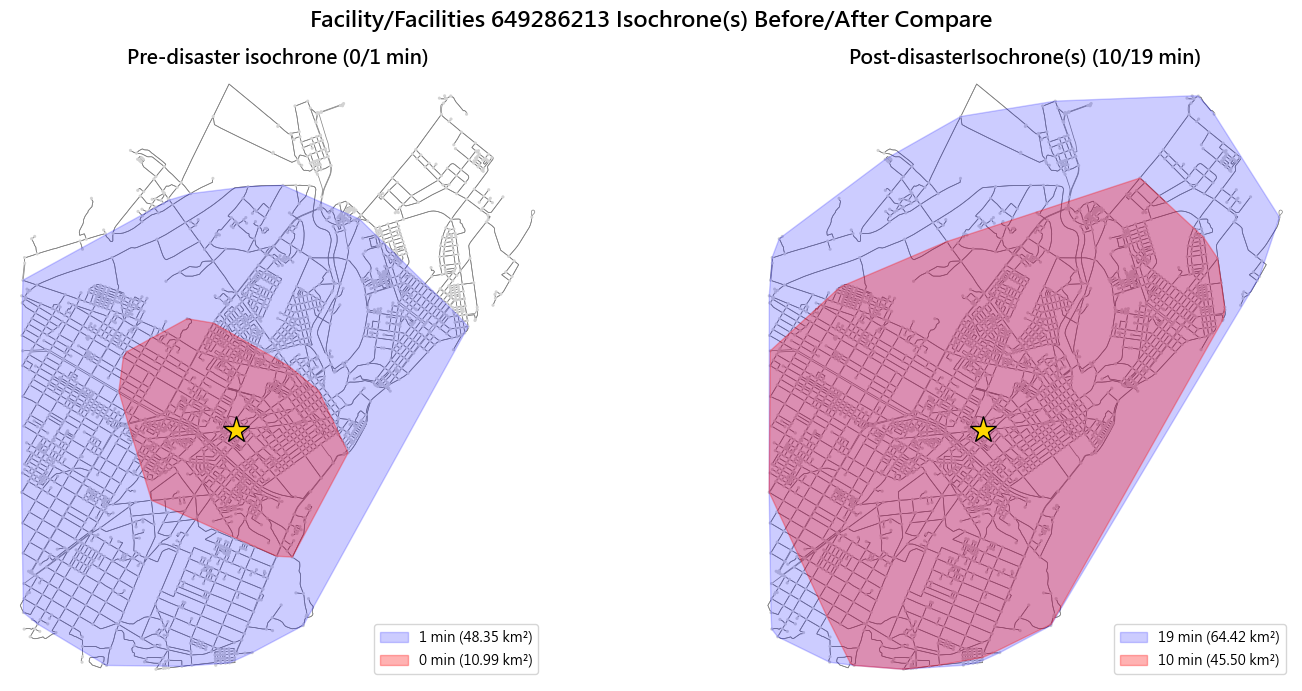

✅ Isochrone(s)Visualization complete


In [15]:
# [S13] Visualize Isochrone Comparison (Adaptive Threshold)

# Draw isochrones for the first critical facility
facility_id = selected_facilities[0][0]

# CalculatePre-disaster/Post-disasterrespective adaptive thresholds
t_short_b, t_long_b = get_adaptive_thresholds(G_dyn, facility_id, 'travel_time')
t_short_a, t_long_a = get_adaptive_thresholds(G_dyn, facility_id, 'travel_time_adj')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

configs = [
    (axes[0], 'travel_time',     f'Pre-disaster isochrone ({t_short_b/60:.0f}/{t_long_b/60:.0f} min)', t_short_b, t_long_b),
    (axes[1], 'travel_time_adj', f'Post-disasterIsochrone(s) ({t_short_a/60:.0f}/{t_long_a/60:.0f} min)', t_short_a, t_long_a),
]

for ax, weight_attr, title, t_short, t_long in configs:
    # Draw background road network
    ox.plot_graph(G_proj, ax=ax, node_size=5, node_color='lightgray',
                 edge_color='gray', edge_linewidth=0.5, show=False)
    
    # CalculateIsochrone(s) (UseAdaptive threshold)
    reachable_short, _ = compute_isochrone(G_dyn, facility_id, weight_attr, t_short)
    reachable_long,  _ = compute_isochrone(G_dyn, facility_id, weight_attr, t_long)
    
    # to polygon and visualize
    poly_long,  area_long  = nodes_to_polygon(G_dyn, reachable_long)
    poly_short, area_short = nodes_to_polygon(G_dyn, reachable_short)
    
    if poly_long:
        x, y = poly_long.exterior.xy
        ax.fill(x, y, alpha=0.2, color='blue', label=f'{t_long/60:.0f} min ({area_long/1e6:.2f} km²)')
    if poly_short:
        x, y = poly_short.exterior.xy
        ax.fill(x, y, alpha=0.3, color='red', label=f'{t_short/60:.0f} min ({area_short/1e6:.2f} km²)')
    
    # Mark starting point
    fx = G_dyn.nodes[facility_id]['x']
    fy = G_dyn.nodes[facility_id]['y']
    ax.plot(fx, fy, marker='*', markersize=20, color='gold',
           markeredgecolor='black', zorder=10)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='lower right')

plt.suptitle(f'Facility/Facilities {facility_id} Isochrone(s) Before/After Compare', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Isochrone(s)Visualization complete")

## Part E: Professional Standards (Infrastructure First)

### Task E.1: Environment Variable Management


In [16]:
# [S14] .env Configuration Example

env_example = """
# Week 7 Network Analysis
NETWORK_DIST=5000
NETWORK_CRS=EPSG:3826
CONGESTION_METHOD=threshold

# Threshold level classification (and Slide 12 Consistent)
# <10mm→cf=0, 10-40mm→cf=0.3, 40-80mm→cf=0.6, >80mm→cf=0.9
CONGESTION_BREAK_1=10
CONGESTION_BREAK_2=40
CONGESTION_BREAK_3=80

# Isochrone Analysis
ISOCHRONE_MINUTES=5,10,15
ALPHA_SHAPE_ALPHA=0.001

# Data Paths
KRIGING_RAINFALL_PATH=data/kriging_rainfall.tif
SHELTER_GEODATAFRAME_PATH=data/shelter_geodataframe.geojson
TERRAIN_RISK_PATH=data/terrain_risk.tif
"""

print("Recommended .env Configuration:")
print(env_example)

# TODO: Create in your project root directory .env file and fill in the above content

Recommended .env Configuration:

# Week 7 Network Analysis
NETWORK_DIST=5000
NETWORK_CRS=EPSG:3826
CONGESTION_METHOD=threshold

# Threshold level classification (and Slide 12 Consistent)
# <10mm→cf=0, 10-40mm→cf=0.3, 40-80mm→cf=0.6, >80mm→cf=0.9
CONGESTION_BREAK_1=10
CONGESTION_BREAK_2=40
CONGESTION_BREAK_3=80

# Isochrone Analysis
ISOCHRONE_MINUTES=5,10,15
ALPHA_SHAPE_ALPHA=0.001

# Data Paths
KRIGING_RAINFALL_PATH=data/kriging_rainfall.tif
SHELTER_GEODATAFRAME_PATH=data/shelter_geodataframe.geojson
TERRAIN_RISK_PATH=data/terrain_risk.tif



### Task E.2: Save Graph as GraphML File


In [17]:
# [S15] Save Road Network as GraphML

import os
import osmnx as ox

# 1. 建立 data 資料夾（如果不存在就自動建立）
os.makedirs("data", exist_ok=True)

# 2. 設定輸出路徑
graphml_path = "../output/hualien_network.graphml"

# 3. 儲存投影後的道路網路
ox.save_graphml(G_proj, graphml_path)
print(f"✅ Road network saved as GraphML: {graphml_path}")

# 4. 測試是否可成功讀回
G_loaded = ox.load_graphml(graphml_path)
print(f"✅ GraphML loaded successfully")
print(f"Node count: {G_loaded.number_of_nodes()}")
print(f"Edge count: {G_loaded.number_of_edges()}")

✅ Road network saved as GraphML: ../output/hualien_network.graphml
✅ GraphML loaded successfully
Node count: 3421
Edge count: 9815


## Part F: AI Strategic Report (Optional, Bonus)

### Task F.1: Use AI Tools to Generate Disaster Prevention Recommendations


In [20]:
import google.generativeai as genai
from dotenv import load_dotenv
print("✅ packages imported successfully")

✅ packages imported successfully


In [21]:
# [S16] Prepare AI Tool Invocation (ChatGPT / Gemini / Claude / Other LLM)

# TODO: Install packages
# pip install google-generativeai

import os
# from google.generativeai import genai

# TODO: Set API Key(s) (Read from environment variables, do not hardcode)
# genai.configure(api_key=os.getenv('GOOGLE_API_KEY'))


# [S16] Prepare AI Tool Invocation (ChatGPT / Gemini / Claude / Other LLM)

# 若尚未安裝，先在 notebook 執行：
# !pip install python-dotenv google-generativeai

import os
from dotenv import load_dotenv

# 1. 載入 .env
load_dotenv()

# 2. 讀取 LLM 設定
llm_provider = os.getenv("LLM_PROVIDER", "gemini").lower()
google_api_key = os.getenv("GOOGLE_API_KEY")
openai_api_key = os.getenv("OPENAI_API_KEY")
anthropic_api_key = os.getenv("ANTHROPIC_API_KEY")

print(f"Selected LLM provider: {llm_provider}")

# 3. 根據不同 provider 準備對應設定
if llm_provider == "gemini":
    if not google_api_key:
        raise ValueError("GOOGLE_API_KEY not found in .env")
    
    import google.generativeai as genai
    genai.configure(api_key=google_api_key)
    print("✅ Gemini API configured successfully")

elif llm_provider == "openai":
    if not openai_api_key:
        raise ValueError("OPENAI_API_KEY not found in .env")
    
    print("✅ OpenAI API key loaded successfully")
    # 後續若要真的呼叫 OpenAI，可再補 client 初始化

elif llm_provider == "anthropic":
    if not anthropic_api_key:
        raise ValueError("ANTHROPIC_API_KEY not found in .env")
    
    print("✅ Anthropic API key loaded successfully")
    # 後續若要真的呼叫 Anthropic，可再補 client 初始化

else:
    raise ValueError("LLM_PROVIDER must be one of: gemini, openai, anthropic")

print("✅ Prepare AI tool invocation complete")

print("Prepare AI tool invocation (Use your preferred LLM)")

Selected LLM provider: gemini
✅ Gemini API configured successfully
✅ Prepare AI tool invocation complete
Prepare AI tool invocation (Use your preferred LLM)


In [35]:
# [S17] Generate AI Strategic Report

import os
from dotenv import load_dotenv
import google.generativeai as genai

# 0. Load .env and configure API
load_dotenv(dotenv_path="../.env", override=True)
google_api_key = os.getenv("GOOGLE_API_KEY")

if not google_api_key:
    raise ValueError("GOOGLE_API_KEY not found in ../.env")

genai.configure(api_key=google_api_key)

# 1. Find a usable text-generation model
candidate_models = []
for m in genai.list_models():
    methods = getattr(m, "supported_generation_methods", [])
    if "generateContent" in methods:
        candidate_models.append(m.name)

print("Usable models:")
for name in candidate_models:
    print("-", name)

# 你可以先自動挑第一個，或手動改成你 list_models() 印出的某個可用模型
if not candidate_models:
    raise ValueError("No model supporting generateContent was found.")

model_name = candidate_models[0]
print(f"\nUsing model: {model_name}")

# 2. Prepare data summary
top_5_info = "\n".join([
    f"#{i}: Node {node_id}, Centrality = {cent:.4f}"
    for i, (node_id, cent) in enumerate(top_5_nodes[:5], 1)
])

iso_table_str = accessibility_table.to_string(index=False)

prompt = f"""
You are a traffic advisor for the Hualien County Disaster Prevention Command Center.

Below are the road network analysis results for Typhoon Fenghuang.

[Bottleneck Intersections: Top 5]
{top_5_info}

[Accessibility Analysis Table]
{iso_table_str}

[Task]
Please act as a disaster prevention and emergency logistics specialist.
Based on the network analysis results above, provide a professional strategic report including:

1. Which road segments, intersections, or areas should be prioritized for rescue or repair, and why
2. Suggested alternative rescue methods for isolated or hard-to-reach areas
3. Recommended priority order for resource allocation
4. A short overall conclusion for decision-makers

Please write clearly and professionally in English.
"""

# 3. Invoke model
model = genai.GenerativeModel(model_name)
response = model.generate_content(prompt)

print("\n🤖 AI Strategy Report:\n")
print(response.text)

Usable models:
- models/gemini-2.5-flash
- models/gemini-2.5-pro
- models/gemini-2.0-flash
- models/gemini-2.0-flash-001
- models/gemini-2.0-flash-lite-001
- models/gemini-2.0-flash-lite
- models/gemini-2.5-flash-preview-tts
- models/gemini-2.5-pro-preview-tts
- models/gemma-3-1b-it
- models/gemma-3-4b-it
- models/gemma-3-12b-it
- models/gemma-3-27b-it
- models/gemma-3n-e4b-it
- models/gemma-3n-e2b-it
- models/gemma-4-26b-a4b-it
- models/gemma-4-31b-it
- models/gemini-flash-latest
- models/gemini-flash-lite-latest
- models/gemini-pro-latest
- models/gemini-2.5-flash-lite
- models/gemini-2.5-flash-image
- models/gemini-3-pro-preview
- models/gemini-3-flash-preview
- models/gemini-3.1-pro-preview
- models/gemini-3.1-pro-preview-customtools
- models/gemini-3.1-flash-lite-preview
- models/gemini-3-pro-image-preview
- models/nano-banana-pro-preview
- models/gemini-3.1-flash-image-preview
- models/lyria-3-clip-preview
- models/lyria-3-pro-preview
- models/gemini-robotics-er-1.5-preview
- mod

**Strategic Report: Hualien County Typhoon Fenghuang Disaster Response**

**To:** Hualien County Disaster Prevention Command Center
**From:** Traffic Advisor / Disaster Prevention & Emergency Logistics Specialist
**Date:** [Current Date]
**Subject:** Post-Typhoon Fenghuang Road Network Analysis and Strategic Recommendations

**Introduction:**
This report provides a professional strategic assessment based on the road network analysis for Typhoon Fenghuang. It identifies critical areas of concern, recommends immediate and sequential actions for rescue and repair, and outlines a priority order for resource allocation to optimize response efforts and mitigate humanitarian impact. The analysis highlights severe isolation due to significant accessibility contractions across key network nodes.

---

### 1. Prioritization for Rescue or Repair

Based on the provided centrality and accessibility analysis, the following areas and interventions are prioritized:

*   **Primary Priority (Immediate Life-Saving & Connectivity Restoration):**
    *   **Node 649286213, Node 649286214, and Node 1061487893:** These three intersections are the absolute highest priority.
        *   **Rationale:** They exhibit the highest centrality scores among the top bottlenecks (0.1402, 0.1394, and 0.1253, respectively), indicating their critical importance to the overall network flow. More critically, the accessibility analysis shows a near-total collapse of reachable areas from these nodes (100.0%, 99.6%, and 99.9% short-distance contraction, and similarly high long-distance contraction). This means communities and populations reliant on these specific intersections are effectively **completely isolated**, with no or extremely limited ground access.
        *   **Action:** Immediate and comprehensive assessment of the road segments leading to and from these nodes is required to identify the precise nature and extent of damage (e.g., landslides, bridge collapses, severe road erosion). Repair efforts must prioritize re-establishing at least one passable lane through or around these specific points to restore critical ground access for emergency services and supplies.

*   **Secondary Priority (Network Stabilization & Redundancy):**
    *   **Node 929963021 and Node 1074772659:** These nodes, while not detailed in the accessibility table, represent the next most critical bottlenecks based on their centrality scores (0.1235 and 0.1157).
        *   **Rationale:** Addressing these bottlenecks after the primary three will significantly improve the overall resilience and redundancy of the road network. Neglecting them could lead to new chokepoints as traffic is rerouted, hindering broader recovery efforts.
        *   **Action:** Initiate assessment and preparatory work for repair on these routes concurrently with or immediately following the primary priority repairs, ensuring a phased approach to network restoration.

---

### 2. Suggested Alternative Rescue Methods for Isolated or Hard-to-Reach Areas

Given the near-complete isolation indicated by the accessibility analysis for the primary bottleneck nodes, conventional ground-based rescue methods may be impossible in the initial stages. Alternative strategies are crucial:

*   **Aerial Operations:**
    *   **Helicopters:** Indispensable for rapid reconnaissance, identifying exact locations of isolated populations, conducting immediate medical evacuations of critically injured individuals, delivering urgent medical supplies, and deploying specialized Search and Rescue (SAR) teams to cut-off areas. They can also ferry initial communication equipment.
    *   **Drones:** For detailed aerial mapping of damaged infrastructure, assessing landslide risks, monitoring floodwaters, and delivering small, critical items like satellite phones, essential medicines, or food rations to individuals in hard-to-reach pockets.

*   **Specialized Ground Teams:**
    *   **Foot Patrols with SAR Units:** For areas where roads are completely impassable but terrain allows, highly skilled SAR teams equipped for wilderness or urban search and rescue, carrying essential supplies, can trek into isolated communities. This is vital for initial welfare checks and identifying immediate needs.
    *   **All-Terrain Vehicles (ATVs) / Unimogs:** If partial paths or less severe damage exists off the main road, these vehicles could be used by specialized teams to navigate difficult terrain where standard emergency vehicles cannot.

*   **Waterborne Transport (if applicable):**
    *   If isolated communities are accessible via rivers or coastal areas, and water conditions are safe, small, agile boats (e.g., rubber rafts, patrol boats) could be deployed by rescue teams for supply delivery and evacuation. Requires careful assessment of currents and debris.

*   **Temporary Infrastructure:**
    *   **Military Engineering Units:** Evaluate the feasibility of rapidly deploying temporary bridges (e.g., Bailey bridges) or creating bypass roads through less damaged terrain to restore minimal vehicular access quickly over short gaps.

---

### 3. Recommended Priority Order for Resource Allocation

Resource allocation should be phased and dynamically managed based on the evolving situation, prioritizing life-saving efforts and re-establishing critical links.

*   **Phase 1: Immediate Life-Saving & Assessment (Initial 0-24 hours)**
    1.  **Search and Rescue (SAR) Teams & Medical First Responders:** Prioritize deployment via aerial assets to areas confirmed or highly suspected to be isolated and populated.
    2.  **Aerial Assets (Helicopters, Drones):** Essential for reconnaissance, damage assessment, identifying isolated populations, and emergency medical evacuation.
    3.  **Emergency Supplies:** Air-drop or helicopter-lift critical life-sustaining supplies (medical kits, water, high-energy food) to the most severely cut-off communities.
    4.  **Communication Assets:** Deploy satellite phones or temporary communication systems to isolated areas and for responding teams.

*   **Phase 2: Emergency Connectivity & Stabilization (Days 1-3)**
    1.  **Road Repair Teams & Heavy Equipment:** Direct all available resources to the primary bottleneck nodes (649286213, 649286214, 1061487893) with the objective of creating at least one passable lane for emergency vehicles and initial supply convoys.
    2.  **Logistics Coordination:** Establish forward operating bases and staging areas for resources and supplies just outside the severely affected zones.
    3.  **Shelter and Sanitation Resources:** Mobilize for displaced populations or those in areas with compromised utilities.

*   **Phase 3: Network Restoration & Long-term Recovery (Days 3+ to Weeks)**
    1.  **Expanded Road Repair Efforts:** Continue systematic repair of secondary bottlenecks (929963021, 1074772659) and other critical road segments to restore full network functionality and redundancy.
    2.  **Infrastructure Engineering & Assessment:** Conduct comprehensive surveys of bridges, culverts, and other vital infrastructure for long-term repair and resilience planning.
    3.  **Community Support & Rehabilitation:** Transition from emergency relief to supporting affected communities in rebuilding, psychosocial support, and restoring essential services.

---

### 4. Overall Conclusion for Decision-Makers

The road network analysis for Typhoon Fenghuang presents a dire situation where multiple critical intersections, specifically **Nodes 649286213, 649286214, and 1061487893**, have effectively severed ground access to substantial areas, indicating near-total isolation.

**Immediate and decisive action is paramount.** Our strategy must prioritize **rapid aerial assessment and life-saving rescue operations** to reach these isolated populations. Concurrently, **all available engineering resources must be deployed without delay** to these three critical nodes to re-establish at least minimal ground access. This dual approach of aerial-led rescue and ground-based connectivity restoration is vital to prevent further humanitarian crises, facilitate comprehensive disaster response, and initiate the long-term recovery of Hualien County.

---

## Part G: AI Diagnostic Log (Required)

Record the problems you encountered and solutions in README.md::

### Common Issues Checklist

- [ ] 「OSMnx extractionTimeoutorIncomplete road network」
- [ ] 「Isochrone polygon shape anomaly (Has holes or too large)」  
- [ ] Kriging raster sampling returns nodata at road segment midpoints
- [ ] Road disconnectionAppeared later NetworkXNoPath — Island determination logic」
- [ ] 「road speed Default value strategy for missing attributes」


In [36]:
# [S18] Generate README.md Framework

readme_template = """# ARIA v4.0 - Hualien Disaster Accessibility Assessment

## Project Overview

This project builds an integrated automatic disaster accessibility assessment system combining road network, rainfall, and terrain data.

## datatosource

- **Road network**: OpenStreetMap (via OSMnx)
- **Rainfall**: Week 6 Kriging Interpolation result(s)
- **terrain**: Week 4 Terrain riskparttype
- **avoiddisasterall**: Week 3 avoiddisasterallpositionsettingandriverstreamdistancedistance

## AI diagnosticbreakdaylog

### 1. OSMnx extraction
**issueissue**: [describedescribeyouencounterto/reach issueissue]
**Solution(s)**: [you solutiondecisionmethod]

### 2. Isochrone(s)multiplepolygon
**issueissue**: [describedescribeyouencounterto/reach issueissue]
**Solution(s)**: [you solutiondecisionmethod]

### 3. Othercourseissue
**issueissue**: [describedescribeyouencounterto/reach issueissue]
**Solution(s)**: [you solutiondecisionmethod]

## corecenterissueappear

- Most fragile bottleneck: ???
- Maximum accessibility loss: ???
- Build rescue priority order: ???

## Submission Checklist

- [ ] ARIA_v4.ipynb (Complete integration and analysis)
- [ ] hualien_network.graphml (Road networkcountdata)
- [ ] README.md (This file + AI diagnosticbreakdaylog)
- [ ] accessibilitybenefit-costtable (DataFrame or CSV)
"""

with open('README_template.md', 'w', encoding='utf-8') as f:
    f.write(readme_template)

print("✅ README.md Framework generated,Please copy to your project")

✅ README.md Framework generated,Please copy to your project


---

## Submission Checklist

1. **GitHub Repo URL**
2. **ARIA_v4.ipynb** — Complete analysis notebook (including execution resultsresult)
3. **hualien_network.graphml** — Road networkcountdatafile
4. **README.md** — hullcontain AI diagnosticbreakdaylog
5. **accessibilitybenefit-costtable** — DataFrame or CSV Format

---

## EvaluationStandard

| itemobjective | compareweight |
|------|------|
| Road networkextractget + basethistravel time + GraphML Save/Archive | 15% |
| Betweenness Centrality + Top 5 Bottleneck + W4 Overlay | 20% |
| dynamicaccessibilityAnalyze (congestionvehicle + Isochrone(s) + contractioncompare) | 30% |
| professionalprojectstandard (.env + GraphML + README + AI daylog) | 15% |
| visualconvertitemquality (Road networklayer/map + Isochrone(s) before/after Compare) | 10% |
| **Bonus**: AI Strategy Report (Tools not limited) | 10% |

---

## Tips and Notes

1. **CRS Consistentproperty**: Road network、avoiddisasterall、Kriging raster All must be projected to EPSG:3826
2. **Speed defaultsetvalue**: OSM `maxspeed` normalnormalmissingloss,use highway typetyperecommendassess (see Demo Cell [3])
3. **Isochrone(s)multiplepolygon**: use `shapely`   `convex_hull` or `concave_hull`
4. **大typeRoad networkeffectcapability**: 花蓮 ~3000 nodes veryfast;allcountycancapabilityneedneed 1-2 partminute
5. **Kriging raster sampling**: Use `rasterio.sample()`, notecoordinatesystem
6. **road disconnectiondetermine**: cf = 0.9: speed reduced to 10%, nearly impassable;If you need to completely remove edges, use `G.remove_edge()`
7. **Threshold level classification**: `<10mm→0, 10-40mm→0.3, 40-80mm→0.6, >80mm→0.9` (and Slide 12 Consistent)